[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sorbonnescai/2026_bootcamp_spatial/blob/main/projects/project2_coastal_water_segmentation.ipynb)

# Project 2 - Segmentation d'images pour la distinction entre eaux côtières et eaux du large à partir des données MODIS/Aqua

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray as xr
from pyresample import geometry, kd_tree
import pyresample
import netCDF4 as nc
import os



In [2]:
import sys
print(sys.executable)

/home/gbaaklini/miniconda3/envs/Botocamp/bin/python


In [3]:
def normalize_with_nan(arr):
    # Exclude NaN values and normalize the array to range [0, 1]
    valid_values = arr[~np.isnan(arr)]
    normalized_values = (valid_values - np.nanmin(valid_values)) / (np.nanmax(valid_values) - np.nanmin(valid_values))

    # Create a new array with NaN values replaced by the normalized values
    normalized_arr = np.empty_like(arr)
    normalized_arr[~np.isnan(arr)] = normalized_values
    normalized_arr[np.isnan(arr)] = np.nan

    return normalized_arr

## Load Data

In [4]:
import os
import gdown

def download_and_unzip(file_id, zip_name, unzip_dir):
    """
    Downloads a Google Drive file using gdown, unzips it into a specific folder,
    and lists the extracted files.
    """
    os.makedirs(unzip_dir, exist_ok=True)

    # Build Google Drive URL
    download_url = f"https://drive.google.com/uc?id={file_id}"
    output_path = os.path.join("./", zip_name)

    print(f"Downloading {zip_name} from Google Drive...")
    gdown.download(download_url, output_path, quiet=False)

    print(f"Unzipping {zip_name} into {unzip_dir}...")
    os.system(f'unzip -o "{output_path}" -d "{unzip_dir}"')

    print(f"Files extracted in {unzip_dir}:")
    os.system(f'ls -lh "{unzip_dir}"')


download_and_unzip("1kfvR4suora_0jzHKI00nb5lAJ74rik1O", "labeled.zip", "./")

# data_brut.zip
download_and_unzip("190qpiN3hFvyNqqHT3kG2dKhRfbszd-5T", "data_brut.zip", "./")

Downloading...
From: https://drive.google.com/uc?id=1kfvR4suora_0jzHKI00nb5lAJ74rik1O
To: /home/gbaaklini/Bureau/labeled.zip
100%|████████████████████████████████████████| 265k/265k [00:00<00:00, 9.58MB/s]


Unzipping labeled.zip into ./...
Archive:  ./labeled.zip
  inflating: ./labeled/20040601_20040608.nc  
  inflating: ./labeled/20040617_20040624.nc  
  inflating: ./labeled/20040703_20040710.nc  
  inflating: ./labeled/20040719_20040726.nc  
  inflating: ./labeled/20040804_20040811.nc  
  inflating: ./labeled/20050509_20050516.nc  
  inflating: ./labeled/20050525_20050601.nc  
  inflating: ./labeled/20050610_20050617.nc  
  inflating: ./labeled/20050626_20050703.nc  
  inflating: ./labeled/20050712_20050719.nc  
  inflating: ./labeled/20050728_20050804.nc  
  inflating: ./labeled/20050813_20050820.nc  
  inflating: ./labeled/20050829_20050905.nc  
  inflating: ./labeled/20070626_20070703.nc  
  inflating: ./labeled/20070712_20070719.nc  
  inflating: ./labeled/20070805_20070812.nc  
  inflating: ./labeled/20070821_20070828.nc  
  inflating: ./labeled/20070906_20070913.nc  
  inflating: ./labeled/20070922_20070929.nc  
  inflating: ./labeled/20071008_20071015.nc  
  inflating: ./labeled/

Downloading...
From (original): https://drive.google.com/uc?id=190qpiN3hFvyNqqHT3kG2dKhRfbszd-5T
From (redirected): https://drive.google.com/uc?id=190qpiN3hFvyNqqHT3kG2dKhRfbszd-5T&confirm=t&uuid=25a8b25d-083f-4d30-a2f6-bc60dfdd131f
To: /home/gbaaklini/Bureau/data_brut.zip
100%|████████████████████████████████████████| 160M/160M [00:08<00:00, 18.6MB/s]


Unzipping data_brut.zip into ./...
Archive:  ./data_brut.zip
  inflating: ./data_brut/AQUA_MODIS.20030125_20030201.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20030125_20030201.L3m.8D.RRS.x_Rrs_678.nc  
  inflating: ./data_brut/AQUA_MODIS.20030109_20030116.L3m.8D.RRS.x_Rrs_412.nc  
  inflating: ./data_brut/AQUA_MODIS.20030109_20030116.L3m.8D.RRS.x_Rrs_678.nc  
  inflating: ./data_brut/AQUA_MODIS.20030306_20030313.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20030306_20030313.L3m.8D.RRS.x_Rrs_555.nc  
  inflating: ./data_brut/AQUA_MODIS.20030306_20030313.L3m.8D.RRS.x_Rrs_678.nc  
  inflating: ./data_brut/AQUA_MODIS.20030330_20030406.L3m.8D.RRS.x_Rrs_678.nc  
  inflating: ./data_brut/AQUA_MODIS.20030407_20030414.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.20030407_20030414.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20030501_20030508.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20030501_20030508.L3m.8

  inflating: ./data_brut/AQUA_MODIS.20150117_20150124.L3m.8D.RRS.x_Rrs_412.nc  
  inflating: ./data_brut/AQUA_MODIS.20150117_20150124.L3m.8D.RRS.x_Rrs_678.nc  
  inflating: ./data_brut/AQUA_MODIS.20150125_20150201.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20150125_20150201.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.20150202_20150209.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20150202_20150209.L3m.8D.RRS.x_Rrs_412.nc  
  inflating: ./data_brut/AQUA_MODIS.20150226_20150305.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.20150226_20150305.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20150306_20150313.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20150306_20150313.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.20150306_20150313.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20150306_20150313.L3m.8D.RRS.x_Rrs_678.nc  
  inflating: ./data_brut/AQUA_MODIS.2015

  inflating: ./data_brut/AQUA_MODIS.20071024_20071031.L3m.8D.RRS.x_Rrs_678.nc  
  inflating: ./data_brut/AQUA_MODIS.20071117_20071124.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.20071117_20071124.L3m.8D.RRS.x_Rrs_555.nc  
  inflating: ./data_brut/AQUA_MODIS.20071125_20071202.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20071125_20071202.L3m.8D.RRS.x_Rrs_412.nc  
  inflating: ./data_brut/AQUA_MODIS.20071125_20071202.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.20071125_20071202.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20080101_20080108.L3m.8D.RRS.x_Rrs_555.nc  
  inflating: ./data_brut/AQUA_MODIS.20080117_20080124.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20080117_20080124.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20080117_20080124.L3m.8D.RRS.x_Rrs_678.nc  
  inflating: ./data_brut/AQUA_MODIS.20080202_20080209.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.2008

  inflating: ./data_brut/AQUA_MODIS.20200617_20200624.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20200617_20200624.L3m.8D.RRS.x_Rrs_555.nc  
  inflating: ./data_brut/AQUA_MODIS.20200625_20200702.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20200625_20200702.L3m.8D.RRS.x_Rrs_412.nc  
  inflating: ./data_brut/AQUA_MODIS.20200625_20200702.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20200703_20200710.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20200703_20200710.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20200711_20200718.L3m.8D.RRS.x_Rrs_412.nc  
  inflating: ./data_brut/AQUA_MODIS.20200727_20200803.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20200727_20200803.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.20200727_20200803.L3m.8D.RRS.x_Rrs_678.nc  
  inflating: ./data_brut/AQUA_MODIS.20200804_20200811.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.2020

  inflating: ./data_brut/AQUA_MODIS.20140109_20140116.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20140117_20140124.L3m.8D.RRS.x_Rrs_555.nc  
  inflating: ./data_brut/AQUA_MODIS.20140125_20140201.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.20140125_20140201.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20140202_20140209.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20140210_20140217.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.20140210_20140217.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20140218_20140225.L3m.8D.RRS.x_Rrs_412.nc  
  inflating: ./data_brut/AQUA_MODIS.20140218_20140225.L3m.8D.RRS.x_Rrs_555.nc  
  inflating: ./data_brut/AQUA_MODIS.20140314_20140321.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20140314_20140321.L3m.8D.RRS.x_Rrs_412.nc  
  inflating: ./data_brut/AQUA_MODIS.20140314_20140321.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.2014

  inflating: ./data_brut/AQUA_MODIS.20060525_20060601.L3m.8D.RRS.x_Rrs_555.nc  
  inflating: ./data_brut/AQUA_MODIS.20060602_20060609.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20060602_20060609.L3m.8D.RRS.x_Rrs_412.nc  
  inflating: ./data_brut/AQUA_MODIS.20060602_20060609.L3m.8D.RRS.x_Rrs_678.nc  
  inflating: ./data_brut/AQUA_MODIS.20060618_20060625.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20060626_20060703.L3m.8D.RRS.x_Rrs_412.nc  
  inflating: ./data_brut/AQUA_MODIS.20060626_20060703.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.20060805_20060812.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20060805_20060812.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.20060805_20060812.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20060813_20060820.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20060821_20060828.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.2006

  inflating: ./data_brut/AQUA_MODIS.20181109_20181116.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.20181109_20181116.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20181109_20181116.L3m.8D.RRS.x_Rrs_678.nc  
  inflating: ./data_brut/AQUA_MODIS.20190117_20190124.L3m.8D.RRS.x_Rrs_488.nc  
  inflating: ./data_brut/AQUA_MODIS.20190210_20190217.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20190226_20190305.L3m.8D.RRS.x_Rrs_412.nc  
  inflating: ./data_brut/AQUA_MODIS.20190306_20190313.L3m.8D.CHL.x_chlor_a.nc  
  inflating: ./data_brut/AQUA_MODIS.20190306_20190313.L3m.8D.RRS.x_Rrs_678.nc  
  inflating: ./data_brut/AQUA_MODIS.20190314_20190321.L3m.8D.RRS.x_Rrs_443.nc  
  inflating: ./data_brut/AQUA_MODIS.20190407_20190414.L3m.8D.RRS.x_Rrs_412.nc  
  inflating: ./data_brut/AQUA_MODIS.20190407_20190414.L3m.8D.RRS.x_Rrs_555.nc  
  inflating: ./data_brut/AQUA_MODIS.20190415_20190422.L3m.8D.RRS.x_Rrs_412.nc  
  inflating: ./data_brut/AQUA_MODIS.2019

In [5]:
### Each day have these parameters:

#RRS.x_Rrs_412    # Remote sensing reflectance at 412 nm
#RRS.x_Rrs_443    # Remote sensing reflectance at 443 nm
#RRS.x_Rrs_488    # Remote sensing reflectance at 488 nm
#RRS.x_Rrs_678    # Remote sensing reflectance at 678 nm
#CHL.x_chlor_a    # Chlorophyll-a concentration




In [6]:
### Step 1 ### Read and plot all the parameters for a random day you select  

#!!!!! Use np.log10 for Chlorophyll 

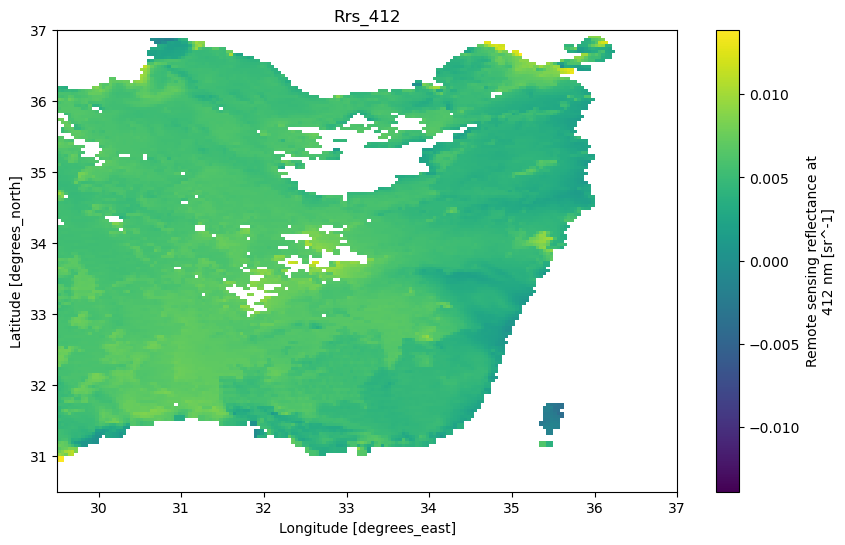

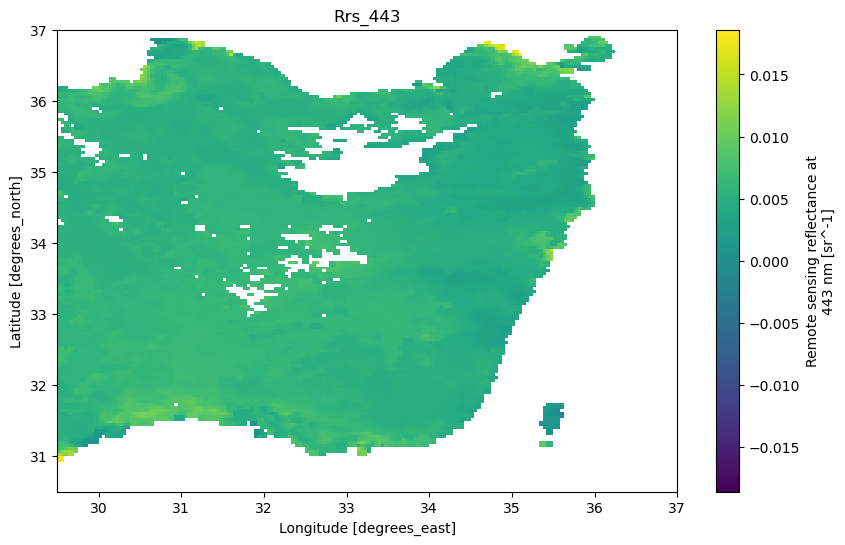

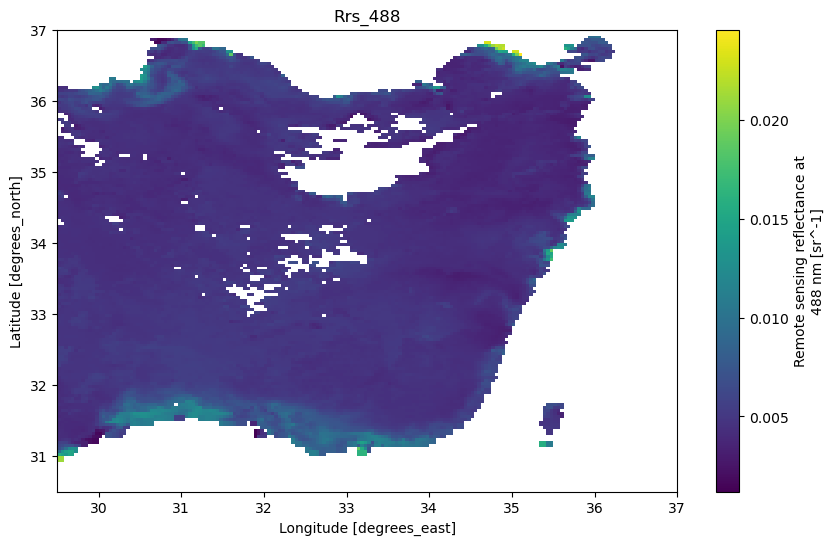

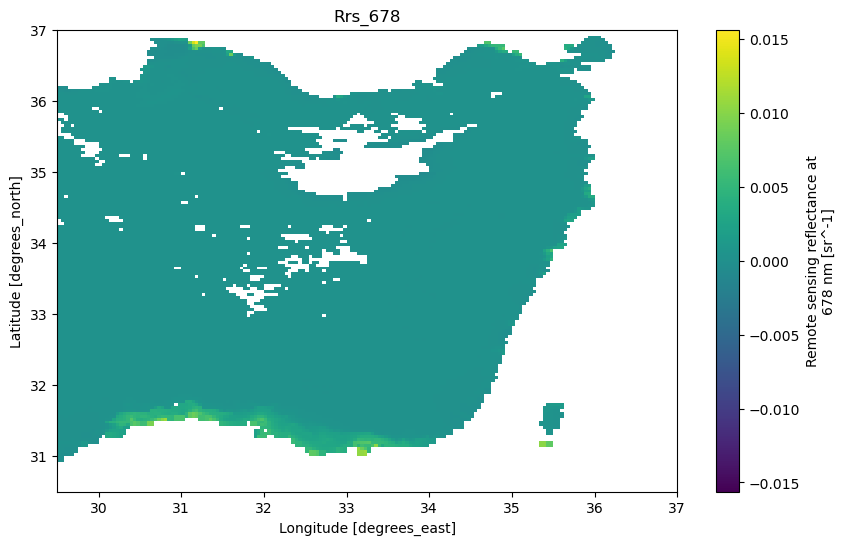

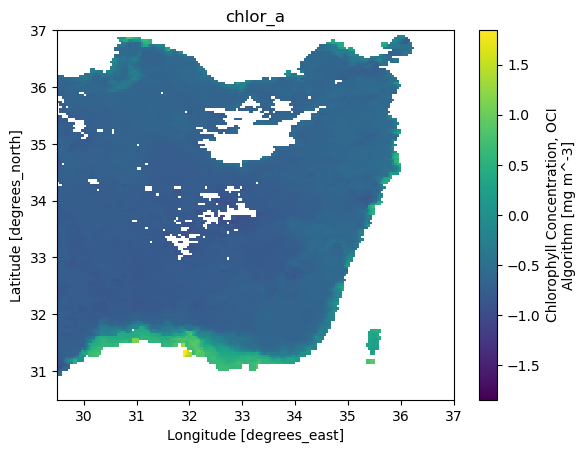

In [7]:

parameters = ['RRS.x_Rrs_412', 'RRS.x_Rrs_443', 'RRS.x_Rrs_488', 'RRS.x_Rrs_678', 'CHL.x_chlor_a']

# 2️⃣ Loop over parameters
for param in parameters:
    
    file_path = f"./data_brut/AQUA_MODIS.20050125_20050201.L3m.8D.{param}.nc"
    ds = xr.open_dataset(file_path)
    var_name = list(ds.data_vars.keys())[0]  # usually the main variable
    
    
    data = ds[var_name]
    lon = ds['lon']
    lat = ds['lat']
    lon=np.array(lon)
    lat=np.array(lat)
 
    if var_name == 'chlor_a':
        np.log10(data).plot(cmap='viridis')
        plt.title(var_name)
        plt.show()
    
    else:
      
        plt.figure(figsize=(10,6))
        data.plot(cmap='viridis')
        plt.title(var_name)
        plt.show()
        
 

In [8]:
#The shape data is 156, 180, for unet 
#In a U-Net, the input dimensions must be divisible by 2 (or by 2ⁿ for n downsampling layers) to ensure that the feature maps align correctly during pooling and upsampling
#You should interpolate all the dataset 

In [9]:
lon_i=np.linspace(29.8,36.2, 128)
lat_i=np.linspace(36.86,30.5, 128)

wf = lambda r: 1/r**2


source_def = geometry.AreaDefinition('source', 'source', 'source',
                                     {'proj': 'latlong', 'lon_0': 0},
                                     len(lon), len(lat),
                                     (np.min(lon), np.min(lat), np.max(lon), np.max(lat)))

# Define the target grid
target_def = geometry.AreaDefinition('target', 'target', 'target',
                                     {'proj': 'latlong', 'lon_0': 0},
                                     len(lon_i), len(lat_i),
                                     (np.min(lon_i), np.min(lat_i), np.max(lon_i), np.max(lat_i)))
radius_of_influence = 50000 

In [48]:

variables_acronym = ['CHL', 'RRS', 'RRS', 'RRS', 'RRS', 'RRS']
variables = ['chlor_a', 'Rrs_412', 'Rrs_443', 'Rrs_488', 'Rrs_555', 'Rrs_678']

destination_path = './merged_filtered_data'
os.makedirs(destination_path, exist_ok=True)

with open('cleaned_file_list.txt', 'r') as f:
    filenames = f.read().splitlines()

nbr_of_days = 0

for days in filenames:
    
    rs_all = []

    for var, acr in zip(variables, variables_acronym):
        
        filepath = f'./data_brut/AQUA_MODIS.{days}.L3m.8D.{acr}.x_{var}.nc'
        print(filepath)
        
        ds = nc.Dataset(filepath, "r")
        
        lon_chl = ds['lon'][:]
        lat_chl = ds['lat'][:]
        
        source_def_chl = geometry.AreaDefinition(
            'source', 'source', 'source',
            {'proj': 'latlong', 'lon_0': 0},
            len(lon_chl), len(lat_chl),
            (np.min(lon_chl), np.min(lat_chl), np.max(lon_chl), np.max(lat_chl))
        )
        
        rs = ds[var][:]
        rs = np.array(rs)
        
        rs[rs < -900] = np.nan
        rs[rs <= 0] = np.nan
        
        rs_interp = pyresample.kd_tree.resample_custom(
            source_def_chl, rs, target_def,
            radius_of_influence=500000,
            neighbours=10,
            weight_funcs=wf,
            fill_value=None
        )
        
        rs_normalized = normalize_with_nan(rs_interp)
        

        
        rs_all.append(rs_normalized)
        
        ds.close()

    rs_all = np.array(rs_all)
    rs_all = np.flip(rs_all, axis=1)
    
    new_filename = f"{destination_path}/{days}.nc"
    
    nc_file = nc.Dataset(new_filename, 'w', format='NETCDF4')
    
    nc_file.createDimension('lon', len(lon_i))
    nc_file.createDimension('lat', len(lat_i))
    nc_file.createDimension('time', rs_all.shape[0])
    
    lon_var = nc_file.createVariable('lon', np.float64, ('lon',))
    lat_var = nc_file.createVariable('lat', np.float64, ('lat',))
    rs_all_var = nc_file.createVariable('rs_all', rs_all.dtype, ('time', 'lat', 'lon'))
    
    lon_var[:] = lon_i[:]
    lat_var[:] = lat_i[:]
    rs_all_var[:] = rs_all
    
    nc_file.close()

    print(f"Saved NetCDF file: {new_filename}")
    
    nbr_of_days += 1

./data_brut/AQUA_MODIS.20030109_20030116.L3m.8D.CHL.x_chlor_a.nc
./data_brut/AQUA_MODIS.20030109_20030116.L3m.8D.RRS.x_Rrs_412.nc
./data_brut/AQUA_MODIS.20030109_20030116.L3m.8D.RRS.x_Rrs_443.nc
./data_brut/AQUA_MODIS.20030109_20030116.L3m.8D.RRS.x_Rrs_488.nc
./data_brut/AQUA_MODIS.20030109_20030116.L3m.8D.RRS.x_Rrs_555.nc
./data_brut/AQUA_MODIS.20030109_20030116.L3m.8D.RRS.x_Rrs_678.nc
Saved NetCDF file: ./merged_filtered_data/20030109_20030116.nc
./data_brut/AQUA_MODIS.20030125_20030201.L3m.8D.CHL.x_chlor_a.nc
./data_brut/AQUA_MODIS.20030125_20030201.L3m.8D.RRS.x_Rrs_412.nc
./data_brut/AQUA_MODIS.20030125_20030201.L3m.8D.RRS.x_Rrs_443.nc
./data_brut/AQUA_MODIS.20030125_20030201.L3m.8D.RRS.x_Rrs_488.nc
./data_brut/AQUA_MODIS.20030125_20030201.L3m.8D.RRS.x_Rrs_555.nc


/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 

./data_brut/AQUA_MODIS.20030125_20030201.L3m.8D.RRS.x_Rrs_678.nc
Saved NetCDF file: ./merged_filtered_data/20030125_20030201.nc
./data_brut/AQUA_MODIS.20030306_20030313.L3m.8D.CHL.x_chlor_a.nc
./data_brut/AQUA_MODIS.20030306_20030313.L3m.8D.RRS.x_Rrs_412.nc
./data_brut/AQUA_MODIS.20030306_20030313.L3m.8D.RRS.x_Rrs_443.nc
./data_brut/AQUA_MODIS.20030306_20030313.L3m.8D.RRS.x_Rrs_488.nc
./data_brut/AQUA_MODIS.20030306_20030313.L3m.8D.RRS.x_Rrs_555.nc
./data_brut/AQUA_MODIS.20030306_20030313.L3m.8D.RRS.x_Rrs_678.nc
Saved NetCDF file: ./merged_filtered_data/20030306_20030313.nc
./data_brut/AQUA_MODIS.20030330_20030406.L3m.8D.CHL.x_chlor_a.nc
./data_brut/AQUA_MODIS.20030330_20030406.L3m.8D.RRS.x_Rrs_412.nc
./data_brut/AQUA_MODIS.20030330_20030406.L3m.8D.RRS.x_Rrs_443.nc


/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 

./data_brut/AQUA_MODIS.20030330_20030406.L3m.8D.RRS.x_Rrs_488.nc
./data_brut/AQUA_MODIS.20030330_20030406.L3m.8D.RRS.x_Rrs_555.nc
./data_brut/AQUA_MODIS.20030330_20030406.L3m.8D.RRS.x_Rrs_678.nc
Saved NetCDF file: ./merged_filtered_data/20030330_20030406.nc
./data_brut/AQUA_MODIS.20030407_20030414.L3m.8D.CHL.x_chlor_a.nc
./data_brut/AQUA_MODIS.20030407_20030414.L3m.8D.RRS.x_Rrs_412.nc
./data_brut/AQUA_MODIS.20030407_20030414.L3m.8D.RRS.x_Rrs_443.nc
./data_brut/AQUA_MODIS.20030407_20030414.L3m.8D.RRS.x_Rrs_488.nc
./data_brut/AQUA_MODIS.20030407_20030414.L3m.8D.RRS.x_Rrs_555.nc
./data_brut/AQUA_MODIS.20030407_20030414.L3m.8D.RRS.x_Rrs_678.nc
Saved NetCDF file: ./merged_filtered_data/20030407_20030414.nc
./data_brut/AQUA_MODIS.20030423_20030430.L3m.8D.CHL.x_chlor_a.nc
./data_brut/AQUA_MODIS.20030423_20030430.L3m.8D.RRS.x_Rrs_412.nc
./data_brut/AQUA_MODIS.20030423_20030430.L3m.8D.RRS.x_Rrs_443.nc


...

/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 

./data_brut/AQUA_MODIS.20221125_20221202.L3m.8D.RRS.x_Rrs_555.nc
./data_brut/AQUA_MODIS.20221125_20221202.L3m.8D.RRS.x_Rrs_678.nc
Saved NetCDF file: ./merged_filtered_data/20221125_20221202.nc
./data_brut/AQUA_MODIS.20221203_20221210.L3m.8D.CHL.x_chlor_a.nc
./data_brut/AQUA_MODIS.20221203_20221210.L3m.8D.RRS.x_Rrs_412.nc
./data_brut/AQUA_MODIS.20221203_20221210.L3m.8D.RRS.x_Rrs_443.nc
./data_brut/AQUA_MODIS.20221203_20221210.L3m.8D.RRS.x_Rrs_488.nc
./data_brut/AQUA_MODIS.20221203_20221210.L3m.8D.RRS.x_Rrs_555.nc
./data_brut/AQUA_MODIS.20221203_20221210.L3m.8D.RRS.x_Rrs_678.nc
Saved NetCDF file: ./merged_filtered_data/20221203_20221210.nc
./data_brut/AQUA_MODIS.20221211_20221218.L3m.8D.CHL.x_chlor_a.nc
./data_brut/AQUA_MODIS.20221211_20221218.L3m.8D.RRS.x_Rrs_412.nc


/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 

./data_brut/AQUA_MODIS.20221211_20221218.L3m.8D.RRS.x_Rrs_443.nc
./data_brut/AQUA_MODIS.20221211_20221218.L3m.8D.RRS.x_Rrs_488.nc
./data_brut/AQUA_MODIS.20221211_20221218.L3m.8D.RRS.x_Rrs_555.nc
./data_brut/AQUA_MODIS.20221211_20221218.L3m.8D.RRS.x_Rrs_678.nc
Saved NetCDF file: ./merged_filtered_data/20221211_20221218.nc
./data_brut/AQUA_MODIS.20221219_20221226.L3m.8D.CHL.x_chlor_a.nc
./data_brut/AQUA_MODIS.20221219_20221226.L3m.8D.RRS.x_Rrs_412.nc
./data_brut/AQUA_MODIS.20221219_20221226.L3m.8D.RRS.x_Rrs_443.nc
./data_brut/AQUA_MODIS.20221219_20221226.L3m.8D.RRS.x_Rrs_488.nc
./data_brut/AQUA_MODIS.20221219_20221226.L3m.8D.RRS.x_Rrs_555.nc
./data_brut/AQUA_MODIS.20221219_20221226.L3m.8D.RRS.x_Rrs_678.nc
Saved NetCDF file: ./merged_filtered_data/20221219_20221226.nc


/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/home/gbaaklini/miniconda3/envs/Botocamp/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 

Loading file: 20080226_20080304.nc


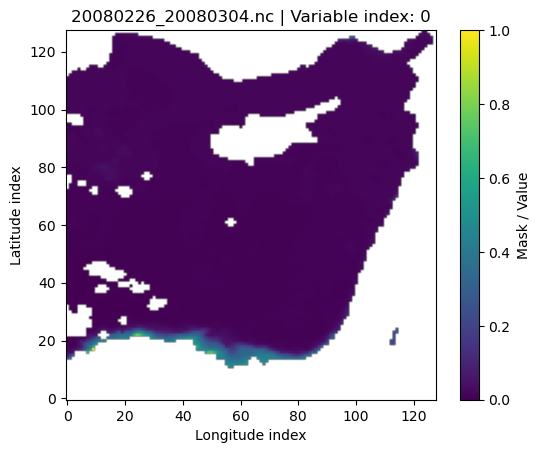

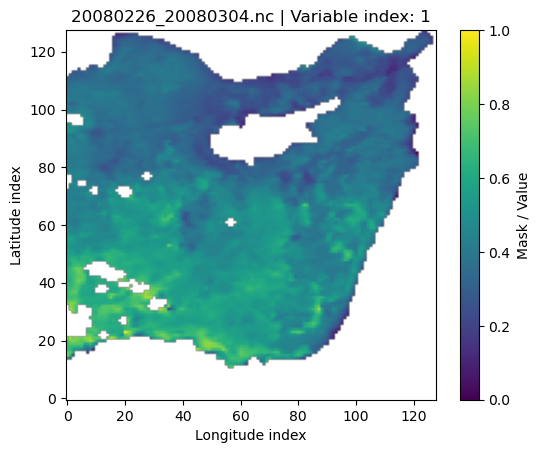

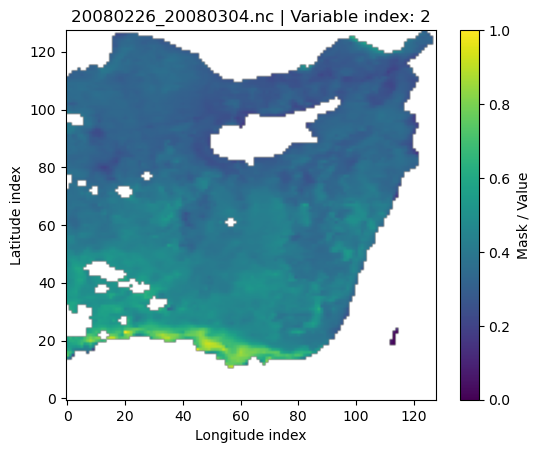

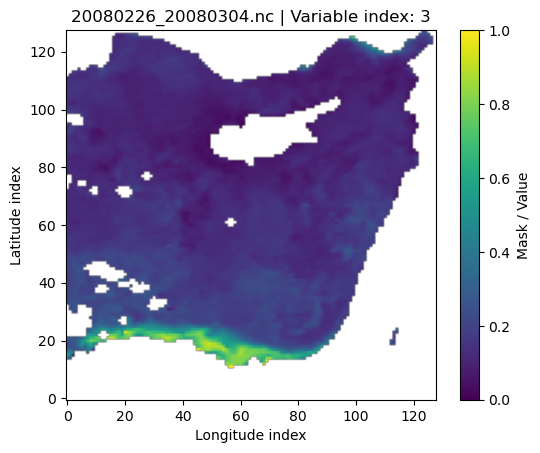

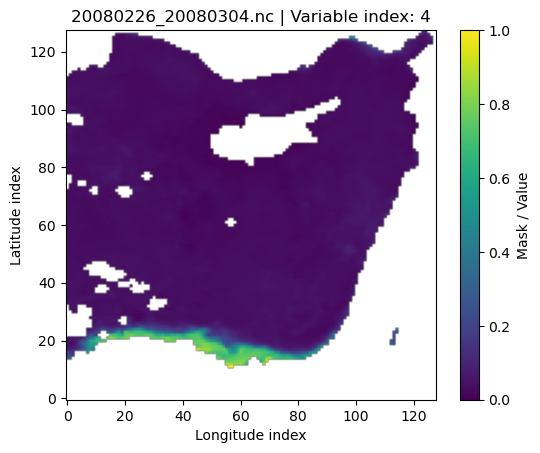

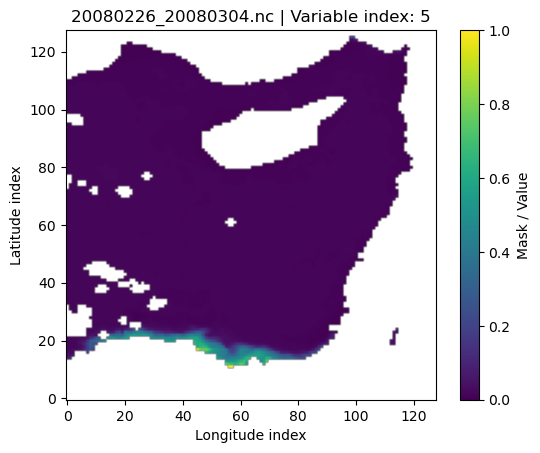

In [72]:
import os
import random
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# Path to your saved files
data_path = './merged_filtered_data'

# Get list of NetCDF files
files = [f for f in os.listdir(data_path) if f.endswith('.nc')]

# Pick a random file
random_file = random.choice(files)
filepath = os.path.join(data_path, random_file)

print(f"Loading file: {random_file}")

# Open file
ds = nc.Dataset(filepath, 'r')

# Read variables
rs_all = ds['rs_all'][:]   # shape: (time, lat, lon)
lon = ds['lon'][:]
lat = ds['lat'][:]

ds.close()

for t in range(0, rs_all.shape[0]):

    data = rs_all[t]

# Plot
    plt.figure()
    plt.imshow(data, origin='lower')
    plt.title(f"{random_file} | Variable index: {t}")
    plt.colorbar(label='Mask / Value')
    plt.xlabel("Longitude index")
    plt.ylabel("Latitude index")
    plt.show()

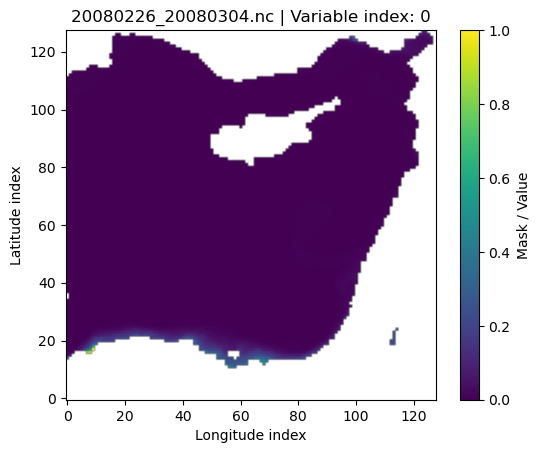

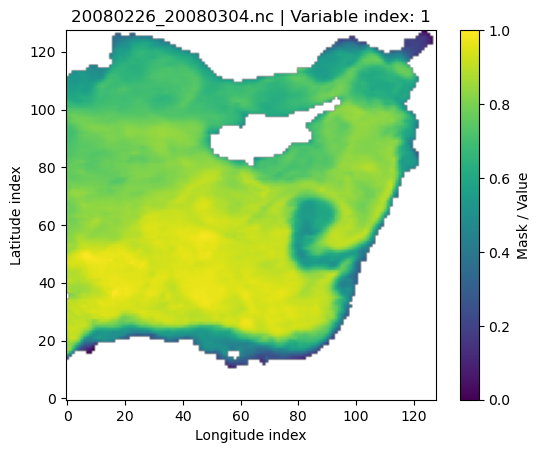

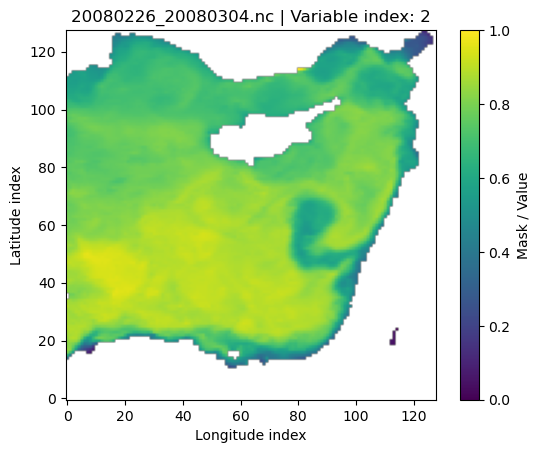

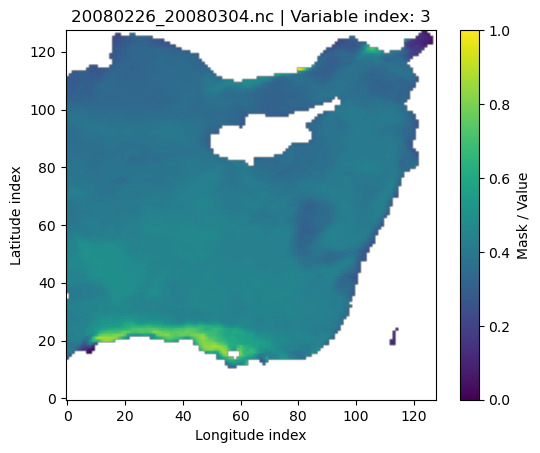

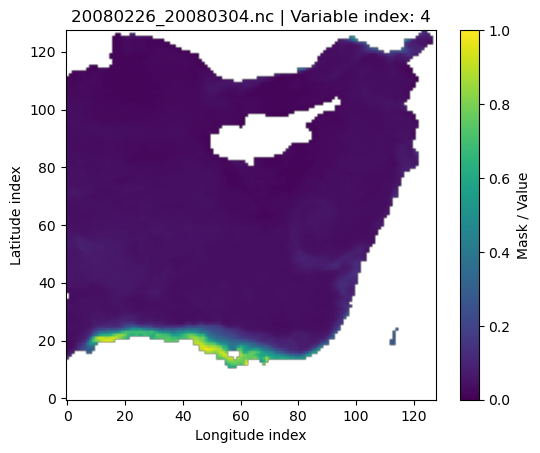

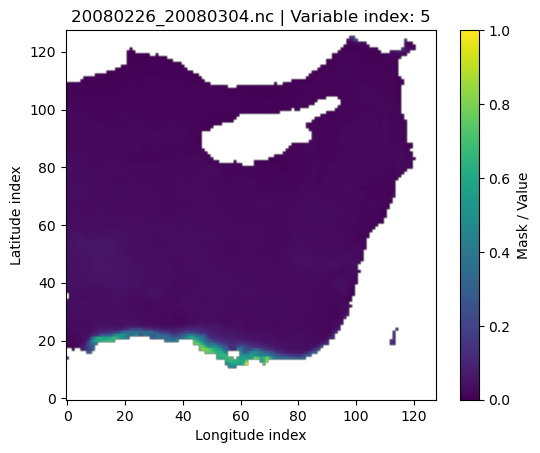

In [74]:
filepath= './merged_filtered_data/20090821_20090828.nc'
ds = nc.Dataset(filepath, 'r')

# Read variables
rs_all = ds['rs_all'][:]   # shape: (time, lat, lon)
lon = ds['lon'][:]
lat = ds['lat'][:]

ds.close()

for t in range(0, rs_all.shape[0]):

    data = rs_all[t]

# Plot
    plt.figure()
    plt.imshow(data, origin='lower')
    plt.title(f"{random_file} | Variable index: {t}")
    plt.colorbar(label='Mask / Value')
    plt.xlabel("Longitude index")
    plt.ylabel("Latitude index")
    plt.show()